##Modelo de regresión para la predicción del precio de automóviles basado en características técnicas

- Angela Lozano Pulido
- Nicolas Cardenas Rodriguez

## 🎯 Motivación y Descripción del Problema

### ¿Por qué es importante este problema?
En el mercado automovilístico, determinar el precio justo de un vehículo
es una tarea compleja que tradicionalmente depende de la experiencia del
vendedor, comparaciones manuales o herramientas costosas. Sin embargo,
gran parte del valor de un automóvil está directamente relacionado con
sus características técnicas: el tamaño del motor, los caballos de fuerza,
el tipo de combustible, entre otros.

Este proyecto busca demostrar que es posible estimar el precio de un
automóvil de forma objetiva y automatizada, basándose únicamente en
sus especificaciones técnicas, sin depender de factores subjetivos
como la marca o la reputación del fabricante.

### ¿Qué beneficios trae usar Inteligencia Artificial?
- **Objetividad:** el modelo evalúa las características técnicas sin
  sesgos de marca o percepción comercial.
- **Velocidad:** una predicción que tomaría horas de investigación manual
  se obtiene en milisegundos.
- **Escalabilidad:** el modelo puede evaluar cientos de vehículos
  simultáneamente.
- **Apoyo a la decisión:** compradores y vendedores obtienen un precio
  de referencia técnico e imparcial.

### ¿Quiénes pueden usar esta solución?
- **Compradores** que quieren saber si el precio de un auto es justo
  según sus especificaciones técnicas.
- **Vendedores y concesionarios** que necesitan fijar precios competitivos
  basados en datos reales.
- **Aseguradoras** que valoran vehículos para calcular primas.
- **Entidades financieras** que necesitan estimar el valor de un vehículo
  como garantía de un crédito.

### ¿Cómo se resuelve actualmente este problema?
Actualmente existen plataformas como **Kelley Blue Book**, **Edmunds** o
**TrueCar** en el mercado estadounidense que estiman precios de vehículos.
Sin embargo, estas herramientas combinan factores técnicos con factores
de mercado como la marca, el año, el kilometraje y la demanda regional,
lo que hace difícil aislar el impacto de las características técnicas puras.
Nuestro modelo se diferencia al trabajar exclusivamente con variables
técnicas del vehículo.

### Aplicación en el contexto local (Colombia)
En Colombia, el mercado automotriz presenta dinámicas particulares: altos
aranceles de importación, variación cambiaria y una oferta concentrada en
segmentos específicos. Herramientas como **TecnoMecánica** o plataformas
como **CarroYa** y **OLX Autos** ofrecen listados de precios pero sin
modelos predictivos basados en características técnicas.

Un modelo como el desarrollado en este proyecto podría adaptarse al
mercado colombiano incorporando datos locales, ayudando a compradores
en ciudades como Bucaramanga, Medellín o Bogotá a tomar decisiones
más informadas al momento de adquirir un vehículo usado o nuevo.

In [1]:
#@title **Librerías**
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.tree     import DecisionTreeRegressor
from sklearn.svm import SVR

In [2]:
#@title **Conexión al dataset**
df_autos = pd.read_csv('https://raw.githubusercontent.com/alalo10/Modelo-de-Regresion---Prediccion-de-precio-de-autos-basado-en-caracteristicas-tecnicas/cb024e58a267bc2301135f703d87a101745b73af/DataSet_Carros_Final.csv')

In [3]:
#@title **Analisis exploratorio**
df_autos.head()

,CarName,fueltype,aspiration,doornumber,carbody,enginetype,cylindernumber,enginesize,boreratio,horsepower,peakrpm,price
0,alfa-romero giulia,gas,std,two,convertible,dohc,four,130,3.47,111,5000,13495.0
1,alfa-romero stelvio,gas,std,two,convertible,dohc,four,130,3.47,111,5000,16500.0
2,alfa-romero Quadrifoglio,gas,std,two,hatchback,ohcv,six,152,2.68,154,5000,16500.0
3,audi 100 ls,gas,std,four,sedan,ohc,four,109,3.19,102,5500,13950.0
4,audi 100ls,gas,std,four,sedan,ohc,five,136,3.19,115,5500,17450.0


In [4]:
# @title
print("---------- Información básica ----------")
df_autos.info()

print("\n")
print("---------- Columnas ----------")
print(list(df_autos.columns))
print("\n")

categorical_columns = ['fueltype', 'aspiration', 'doornumber', 'carbody', 'enginetype', 'cylindernumber']
print("Columnas categóricas: ",categorical_columns )

numerical_columns = ['enginesize', 'boreratio', 'horsepower', 'peakrpm', 'price']
print("Columnas numéricas: ",numerical_columns )

print("\n")
print("---------- Valores únicos en las columnas alfanuméricase ----------")
for col in categorical_columns:
    print(f"Category in {col} is : {df_autos[col].unique()}")


---------- Información básica ----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CarName         305 non-null    object 
 1   fueltype        305 non-null    object 
 2   aspiration      305 non-null    object 
 3   doornumber      305 non-null    object 
 4   carbody         305 non-null    object 
 5   enginetype      305 non-null    object 
 6   cylindernumber  305 non-null    object 
 7   enginesize      305 non-null    int64  
 8   boreratio       305 non-null    float64
 9   horsepower      305 non-null    int64  
 10  peakrpm         305 non-null    int64  
 11  price           305 non-null    float64
dtypes: float64(2), int64(3), object(7)
memory usage: 28.7+ KB


---------- Columnas ----------
['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'enginetype', 'cylindernumber', 'enginesize', 'boreratio', 'horse

## 🧹 Estrategia de Limpieza y Preparación de Datos

### Verificación de calidad del dataset

| Criterio                  | Resultado                        |
|---------------------------|----------------------------------|
| Valores nulos             | 0 — ninguna columna tiene NaN    |
| Filas duplicadas          | 0 — todos los registros son únicos |
| Tipos de datos            | Correctos desde la carga         |
| Rango de valores          | Coherente con el dominio del problema |
| Variables irrelevantes    | CarName excluida del modelo      |

Dado que el dataset no presentó problemas de calidad, no fue necesario
aplicar imputación ni eliminación de registros. La preparación se centró
en la transformación de variables para hacerlas compatibles con los
modelos de Machine Learning.



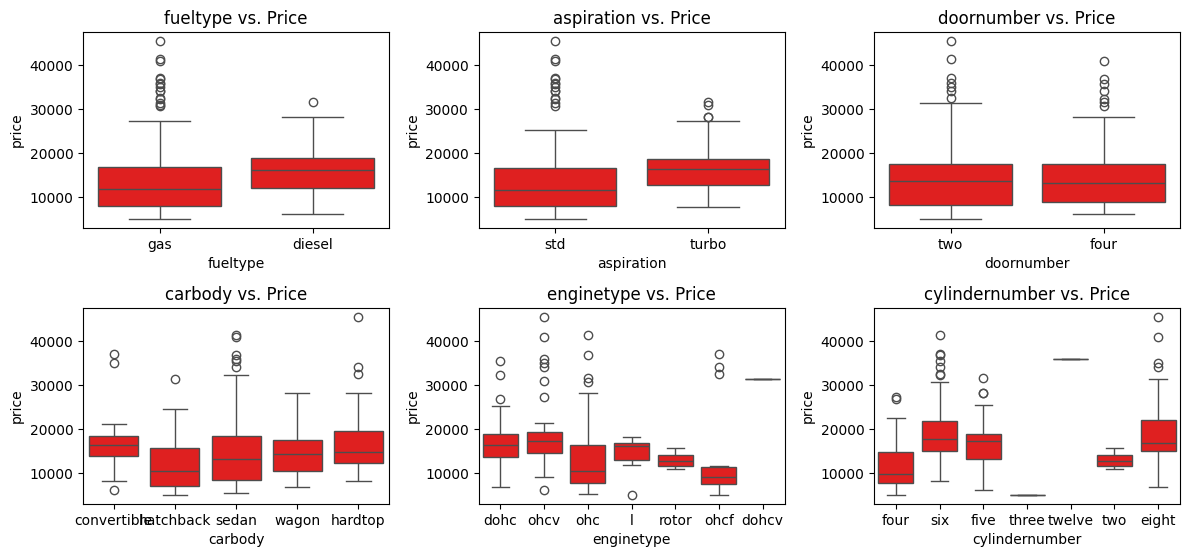

In [5]:
#@title **Diagramas de caja y bigote**: Columnas categóricas vs el precio

plt.figure(figsize=(12, 8))
for feature in categorical_columns:
    plt.subplot(3, 3, categorical_columns.index(feature) + 1)
    sns.boxplot(data=df_autos, x=feature, y='price', color='red')
    plt.title(f'{feature} vs. Price')
plt.tight_layout()
plt.show()

## 📊 Análisis de Box Plots — Variables Categóricas vs Precio

### fueltype vs Price
Los autos a **diesel tienen una mediana de precio más alta** que los de gasolina. Sin embargo, gasolina presenta más outliers hacia valores altos, lo que indica la existencia de autos de gasolina de alta gama. La mayoría de registros del dataset corresponden a autos a gasolina.

### Aspiration vs Price
Los autos **turbo son notablemente más caros** en mediana que los de aspiración estándar. Además, su caja es más amplia, lo que refleja mayor variación en los precios. La aspiración turbo es un predictor relevante del precio.

### Doornumber vs Price
**No existe diferencia significativa** entre autos de 2 y 4 puertas — las medianas son prácticamente iguales. Esta variable probablemente no aporte información relevante al modelo de regresión.

### Carbody vs Price
Los tipos **convertible y hardtop** concentran los precios más altos, mientras que **hatchback y sedan** corresponden a los segmentos más económicos. Wagon presenta alta variabilidad. El tipo de carrocería discrimina bien el precio.

### Enginetype vs Price
**dohcv** registra el precio más alto pero cuenta con un solo auto en el dataset (línea plana). **ohc** es el tipo más común y económico. **dohc** presenta precios altos con considerable variación, rotor y ohcf se ubican en el segmento más bajo.

### Cylindernumber vs Price
Los motores de **ocho y seis cilindros** corresponden a los autos más costosos. **dos, tres y doce** tienen muy pocos registros. Los autos de **cuatro cilindros** son los más económicos y abundantes, mientras que **cinco cilindros** muestra buena variación hacia precios altos.

> **Conclusión:** `aspiration`, `carbody`, `cylindernumber` y `enginetype` son las variables categóricas con mayor influencia sobre el precio. `doornumber` presenta la menor capacidad discriminativa y podría excluirse del modelo.

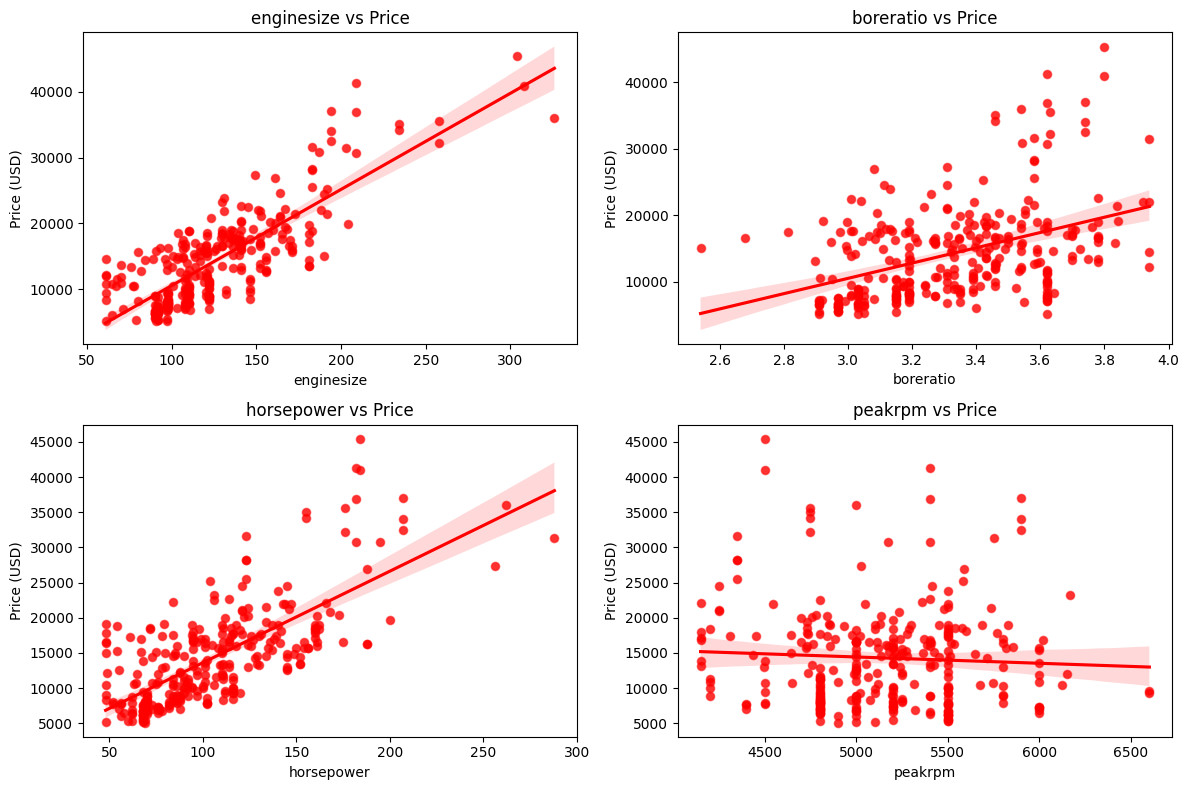

In [6]:
#@title **Diagramas de Dispersión**: Columnas numéricas vs el precio

plt.figure(figsize=(12, 8))
numerical_features = [col for col in numerical_columns if col != 'price']
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(data=df_autos, x=feature, y='price', color='red', alpha=0.6)
    sns.regplot(data=df_autos, x=feature, y='price', color='red',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f'{feature} vs Price')
    plt.xlabel(feature)
    plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

## 📊 Análisis de Scatter Plots — Variables Numéricas vs Precio

### Enginesize vs Price
**Correlación positiva muy fuerte.** A mayor tamaño del motor, mayor precio de
manera casi lineal. Los puntos siguen muy de cerca la línea de tendencia y la
banda de confianza es estrecha. Es probablemente la variable numérica
más predictiva del modelo.

### Boreratio vs Price
**Correlación positiva débil.** Los puntos están muy dispersos alrededor de la
línea y la banda de confianza es amplia. Existe una tendencia leve al alza pero
con mucho ruido. Aportará poco al modelo.

### Horsepower vs Price
**Correlación positiva fuerte**, muy similar a enginesize. A mayor cantidad de
caballos de fuerza, mayor precio de forma bastante consistente. Presenta algunos
outliers en valores altos pero la tendencia es clara. Es la segunda variable
numérica más predictiva del grupo.

### Peakrpm vs Price
**Correlación negativa muy débil**, casi inexistente. La línea es prácticamente
plana y los puntos están completamente dispersos. Las RPM máximas no explican
el precio y probablemente sean la variable numérica menos útil del modelo.

---
> **Conclusión:** `enginesize` y `horsepower` son las variables numéricas con mayor poder predictivo sobre el precio. `boreratio` aporta información pero con considerable ruido. `peakrpm` prácticamente no discrimina el precio y podría descartarse junto con `doornumber` en una etapa de selección de variables.

In [7]:
#@title **LabelEncoder:** aplicamos valores binarios a las categorias
le = LabelEncoder()

# Construir una tabla por columna
tablas_html = []
for col in categorical_columns:
    valores  = df_autos[col].unique()
    codigos  = le.fit_transform(valores)
    tabla    = pd.DataFrame({
        'Categoría': valores,
        'Código'   : codigos
    }).sort_values('Código').reset_index(drop=True)

    html = tabla.style\
        .hide(axis='index')\
        .set_caption(f'🔢 {col}')\
        .set_table_styles([
            {'selector': 'caption',
             'props': 'font-size:13px; font-weight:bold; text-align:center; padding:4px 0;'},
            {'selector': 'thead th',
             'props': 'background-color:red; color:white; text-align:center; padding:5px 12px;'},
            {'selector': 'tbody td',
             'props': 'text-align:center; padding:5px 12px;'},
            {'selector': 'tbody tr:nth-child(even)',
             'props': 'background-color:#f1f8e9;'},
            {'selector': 'table',
             'props': 'border-collapse:collapse; font-size:12px;'},
        ]).to_html()
    tablas_html.append(f'<div style="margin:8px;">{html}</div>')

# Mostrar en 2 filas de 3 tablas cada una
fila1 = '<div style="display:flex; flex-wrap:wrap; justify-content:center;">' \
      + ''.join(tablas_html[:3]) + '</div>'
fila2 = '<div style="display:flex; flex-wrap:wrap; justify-content:center;">' \
      + ''.join(tablas_html[3:]) + '</div>'

display(HTML(fila1 + fila2))

# Aplicar el encoding al df
for col in categorical_columns:
    df_autos[col] = le.fit_transform(df_autos[col])

Categoría,Código
diesel,0
gas,1
Categoría,Código
std,0
turbo,1
Categoría,Código
four,0
two,1
Categoría,Código
convertible,0


Random Forest        → R²: 0.8226 | MAE: 2427.01 USD
SVM (linear)         → R²: 0.7391 | MAE: 3023.13 USD
Decision Tree        → R²: 0.6873 | MAE: 3060.82 USD


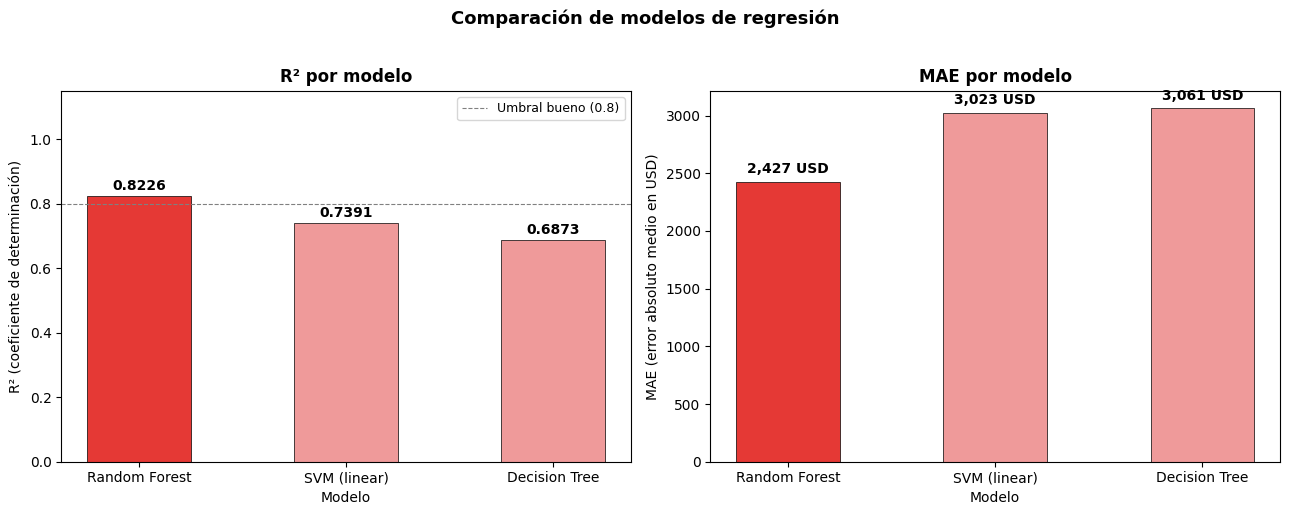


Modelo seleccionado para el predictor: Random Forest (R²: 0.8226)


In [15]:
#@title 📊 Comparación de Modelos de Regresión

# ── Definición de modelos ─────────────────────────────────────────────────
modelos = {
    'Random Forest'  : RandomForestRegressor(n_estimators=18, random_state=21),
    'SVM (linear)'   : SVR(kernel='linear'),
    'Decision Tree'  : DecisionTreeRegressor(max_depth=15, random_state=21),
}

# ── Entrenamiento y evaluación ────────────────────────────────────────────
resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    resultados[nombre] = {
        'modelo' : modelo,
        'y_pred' : y_pred,
        'MAE'    : mean_absolute_error(y_test, y_pred),
        'R2'     : r2_score(y_test, y_pred),
    }
    print(f"{nombre:<20} → R²: {resultados[nombre]['R2']:.4f} | MAE: {resultados[nombre]['MAE']:.2f} USD")

# ── Gráfica comparativa R² y MAE ─────────────────────────────────────────
nombres  = list(resultados.keys())
r2s      = [resultados[n]['R2']  for n in nombres]
maes     = [resultados[n]['MAE'] for n in nombres]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Subgráfica 1: R² ──────────────────────────────────────────────────────
colores_r2 = ['#e53935', '#ef9a9a', '#ef9a9a']
barras_r2  = ax1.bar(nombres, r2s, color=colores_r2, edgecolor='black', linewidth=0.5, width=0.5)

for barra, valor in zip(barras_r2, r2s):
    ax1.text(barra.get_x() + barra.get_width() / 2,
             valor + 0.01,
             f'{valor:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_ylim(0, 1.15)
ax1.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, label='Umbral bueno (0.8)')
ax1.set_title('R² por modelo', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² (coeficiente de determinación)')
ax1.set_xlabel('Modelo')
ax1.legend(fontsize=9)

# ── Subgráfica 2: MAE ─────────────────────────────────────────────────────
colores_mae = ['#e53935', '#ef9a9a', '#ef9a9a']
barras_mae  = ax2.bar(nombres, maes, color=colores_mae, edgecolor='black', linewidth=0.5, width=0.5)

for barra, valor in zip(barras_mae, maes):
    ax2.text(barra.get_x() + barra.get_width() / 2,
             valor + 50,
             f'{valor:,.0f} USD',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_title('MAE por modelo', fontsize=12, fontweight='bold')
ax2.set_ylabel('MAE (error absoluto medio en USD)')
ax2.set_xlabel('Modelo')

plt.suptitle('Comparación de modelos de regresión', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Guardar el mejor modelo para el predictor ─────────────────────────────
mejor_nombre = max(resultados, key=lambda n: resultados[n]['R2'])
est          = resultados[mejor_nombre]['modelo']
print(f"\nModelo seleccionado para el predictor: {mejor_nombre} (R²: {resultados[mejor_nombre]['R2']:.4f})")

## 📊 Resultados del Modelo — Random Forest Regressor

| Métrica | Valor |
|---|---|
| **Muestras de entrenamiento** | 244 (80%) |
| **Muestras de prueba** | 61 (20%) |
| **n_estimators** | 18 |
| **MAE** | $2,427.01 USD |
| **R²** | 0.823 |


### Interpretación

El modelo de **Random Forest Regressor** entrenado con 244 muestras logra un
coeficiente de determinación **R² = 0.823**, lo que indica que explica el **82.3% de la variación en el precio** de los automóviles a partir de sus características técnicas.

El **MAE de 2,427 USD** refleja que, en promedio, el modelo se desvía en ese
valor respecto al precio real, sobre un rango de precios que va de 5,000 a
45,400 USD es un error relativo razonable dado el alcance del dataset.

El 17.7% restante de variación no explicada es consistente con el planteamiento
del problema: factores externos como la marca, la reputación del fabricante o
el año del vehículo influyen en el precio pero no forman parte de las variables
técnicas del dataset.

---
> **Conclusión:** El modelo logra una predicción satisfactoria del precio basándose
> únicamente en características técnicas, con un R² de 0.823 que lo ubica en un
> rango de desempeño bueno según los estándares de regresión.

In [16]:
#@title **🏎️ Predictor de Precio de Automóvil**
import ipywidgets as widgets
from IPython.display import display, HTML
import numpy as np

# ── Opciones originales del dataset ──────────────────────────────────────
opciones = {
    'fueltype'      : ['gas', 'diesel'],
    'aspiration'    : ['std', 'turbo'],
    'doornumber'    : ['two', 'four'],
    'carbody'       : ['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop'],
    'enginetype'    : ['dohc', 'ohcv', 'ohc', 'l', 'rotor', 'ohcf'],
    'cylindernumber': ['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
}

# ── Mapeo manual consistente con el LabelEncoder del entrenamiento ────────
mapeo = {
    'fueltype'      : {'diesel': 0, 'gas': 1},
    'aspiration'    : {'std': 0, 'turbo': 1},
    'doornumber'    : {'four': 0, 'two': 1},
    'carbody'       : {'convertible': 0, 'hardtop': 1, 'hatchback': 2, 'sedan': 3, 'wagon': 4},
    'enginetype'    : {'dohc': 0, 'dohcv': 1, 'l': 2, 'ohc': 3, 'ohcf': 4, 'ohcv': 5, 'rotor': 6},
    'cylindernumber': {'eight': 0, 'five': 1, 'four': 2, 'six': 3, 'three': 4, 'twelve': 5, 'two': 6},
}

estilo_label = {'description_width': '140px'}
ancho        = widgets.Layout(width='340px')

# ── Widgets categóricos (dropdown) ────────────────────────────────────────
w_fueltype       = widgets.Dropdown(options=opciones['fueltype'],       description='Combustible:',  style=estilo_label, layout=ancho)
w_aspiration     = widgets.Dropdown(options=opciones['aspiration'],     description='Aspiración:',   style=estilo_label, layout=ancho)
w_doornumber     = widgets.Dropdown(options=opciones['doornumber'],     description='Puertas:',      style=estilo_label, layout=ancho)
w_carbody        = widgets.Dropdown(options=opciones['carbody'],        description='Carrocería:',   style=estilo_label, layout=ancho)
w_enginetype     = widgets.Dropdown(options=opciones['enginetype'],     description='Tipo motor:',   style=estilo_label, layout=ancho)
w_cylindernumber = widgets.Dropdown(options=opciones['cylindernumber'], description='Cilindros:',    style=estilo_label, layout=ancho)

# ── Widgets numéricos (texto libre) ──────────────────────────────────────
w_enginesize = widgets.BoundedIntText(  value=130,  min=61,   max=326,  description='Motor (cc):',  style=estilo_label, layout=ancho)
w_boreratio  = widgets.BoundedFloatText(value=3.0,  min=2.54, max=3.94, description='Boreratio:',   style=estilo_label, layout=ancho, step=0.01)
w_horsepower = widgets.BoundedIntText(  value=100,  min=48,   max=288,  description='Horsepower:',  style=estilo_label, layout=ancho)
w_peakrpm    = widgets.BoundedIntText(  value=5000, min=4150, max=6600, description='Peak RPM:',    style=estilo_label, layout=ancho)

# ── Botón y salida ────────────────────────────────────────────────────────
btn    = widgets.Button(description='Predecir Precio', button_style='success', icon='search', layout=widgets.Layout(width='200px', height='40px'))
salida = widgets.Output()

# ── Función de predicción ─────────────────────────────────────────────────
def predecir(b):
    salida.clear_output()
    with salida:
        try:
            f1 = mapeo['fueltype'][w_fueltype.value]
            f2 = mapeo['aspiration'][w_aspiration.value]
            f3 = mapeo['doornumber'][w_doornumber.value]
            f4 = mapeo['carbody'][w_carbody.value]
            f5 = mapeo['enginetype'][w_enginetype.value]
            f6 = mapeo['cylindernumber'][w_cylindernumber.value]
            f7  = int(w_enginesize.value)
            f8  = float(w_boreratio.value)
            f9  = int(w_horsepower.value)
            f10 = int(w_peakrpm.value)

            X_input = np.array([[f1, f2, f3, f4, f5, f6, f7, f8, f9, f10]])
            precio  = est.predict(X_input)[0]

            display(HTML(f"""
            <div style="
                margin-top: 16px;
                padding: 20px 30px;
                border-radius: 12px;
                border: 2px solid #2e7d32;
                background-color: #f1f8e9;
                text-align: center;
                font-family: Arial, sans-serif;
            ">
                <p style="font-size:14px; color:#555; margin:0 0 6px 0;">Precio estimado del automóvil</p>
                <p style="font-size:32px; font-weight:bold; color:#2e7d32; margin:0;">
                    {precio:,.0f} USD
                </p>
                <p style="font-size:12px; color:#888; margin:8px 0 0 0;">
                    Basado en las características técnicas ingresadas
                </p>
            </div>
            """))

        except Exception as e:
            display(HTML(f"""
            <div style="
                margin-top: 16px;
                padding: 16px 24px;
                border-radius: 12px;
                border: 2px solid #c62828;
                background-color: #ffebee;
                text-align: center;
                font-family: Arial, sans-serif;
            ">
                <p style="font-size:14px; color:#c62828; margin:0;">
                    Error: {str(e)}
                </p>
            </div>
            """))

btn.on_click(predecir)

# ── Layout final ──────────────────────────────────────────────────────────
display(HTML("<h3 style='font-family:Arial; color:#2e7d32;'>🏎️ Predictor de Precio de Automóvil</h3>"))
display(HTML("<p style='font-family:Arial; font-size:13px; color:#555;'>Selecciona las características técnicas del vehículo y presiona <b>Predecir Precio</b>.</p>"))

col1 = widgets.VBox([w_fueltype, w_aspiration, w_doornumber, w_carbody, w_enginetype, w_cylindernumber])
col2 = widgets.VBox([w_enginesize, w_boreratio, w_horsepower, w_peakrpm])

display(widgets.HBox([col1, col2]))
display(widgets.HBox([btn], layout=widgets.Layout(justify_content='center', margin='16px 0')))
display(salida)

Output()

CROSS-VALIDATION — REGRESIÓN (R²)
SVM (linear)         | K=10 → mean=0.0413  std=0.0262
SVM (linear)         | K=20 → mean=0.0010  std=0.1240
SVM (linear)         | K=50 → mean=-0.4606  std=1.4818

Decision Tree        | K=10 → mean=0.6554  std=0.2210
Decision Tree        | K=20 → mean=0.4897  std=0.5555
Decision Tree        | K=50 → mean=0.2666  std=1.0005

Random Forest        | K=10 → mean=0.8048  std=0.1095
Random Forest        | K=20 → mean=0.7640  std=0.2227
Random Forest        | K=50 → mean=0.6058  std=0.4116



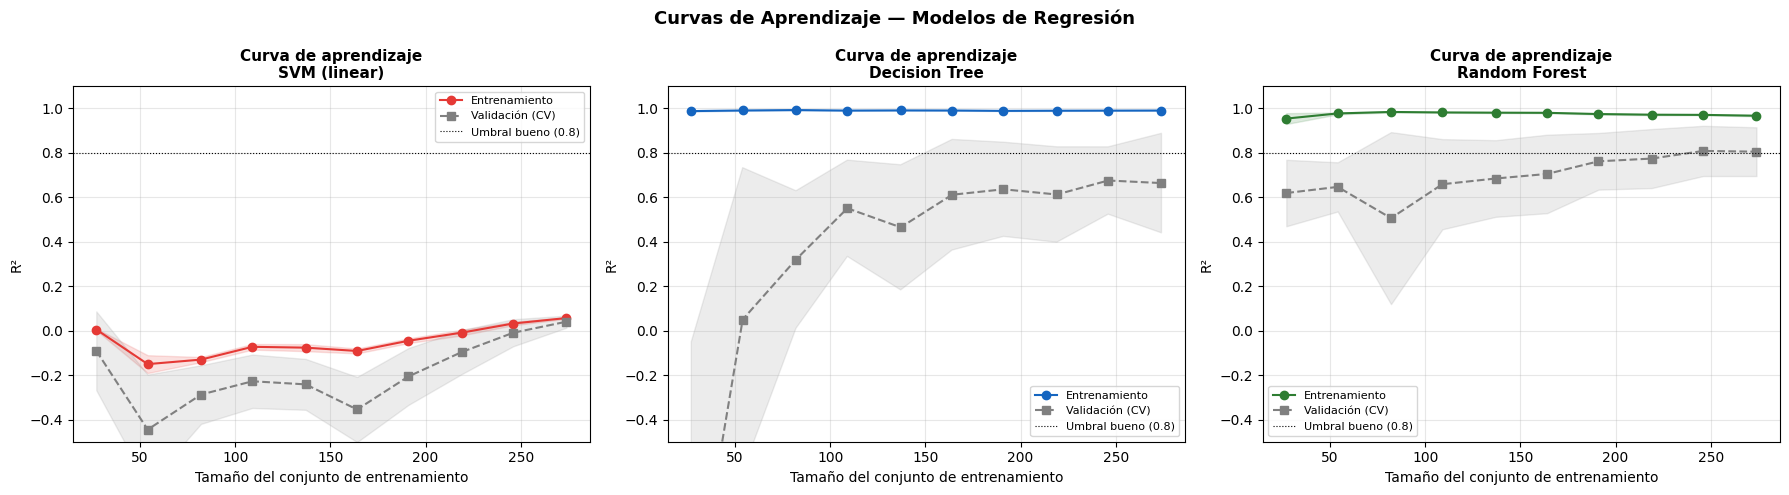

In [22]:
# @title **Cross-Validation y Curvas de Aprendizaje — Regresión**
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Escalamos X para que SVM funcione correctamente
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_reg = df_autos['price'].values

modelos_reg = [
    ("SVM (linear)",  SVR(kernel='linear')),
    ("Decision Tree", DecisionTreeRegressor(max_depth=15, random_state=21)),
    ("Random Forest", RandomForestRegressor(n_estimators=18, random_state=21)),
]

Ks = [10, 20, 50]

# ════════════════════════════════════════════════════════════════════
print("=" * 70)
print("CROSS-VALIDATION — REGRESIÓN (R²)")
print("=" * 70)

for nombre, modelo in modelos_reg:
    for k in Ks:
        cv    = KFold(n_splits=k, shuffle=True, random_state=21)
        score = cross_val_score(modelo, X_scaled, y_reg, cv=cv, scoring='r2')
        print(f"{nombre:20s} | K={k:2d} → mean={score.mean():.4f}  std={score.std():.4f}")
    print()

# ════════════════════════════════════════════════════════════════════
# @title **Curvas de Aprendizaje — Modelos de Regresión**
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colores = ['#e53935', '#1565c0', '#2e7d32']

for ax, (nombre, modelo), color in zip(axes, modelos_reg, colores):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X_scaled, y_reg,
        cv=KFold(n_splits=10, shuffle=True, random_state=21),
        scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-',  color=color,   label='Entrenamiento')
    ax.plot(train_sizes, val_mean,   's--', color='gray',  label='Validación (CV)')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=color)
    ax.fill_between(train_sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.15, color='gray')

    ax.set_title(f'Curva de aprendizaje\n{nombre}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('R²')
    ax.set_ylim(-0.5, 1.1)
    ax.axhline(0.8, color='black', linestyle=':', linewidth=0.8, label='Umbral bueno (0.8)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje — Modelos de Regresión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Análisis de Resultados — Cross-Validation y Curvas de Aprendizaje

### ¿Qué significa cada número?
- **mean**: el R² promedio entre todos los folds. Más cercano a 1.0 = mejor.
- **std**: qué tan dispares fueron los resultados entre folds. Más cercano a 0 = más estable.

---

### 🔴 SVM (linear) — Muy mal rendimiento

| K | Mean R² | Interpretación |
|---|---|---|
| 10 | 0.04 | Casi no explica nada del precio |
| 20 | 0.00 | Equivale a adivinar |
| 50 | -0.46 | Peor que adivinar |

El SVM lineal **no sirve para este problema**. La relación entre las características técnicas y el precio no es lineal, por lo que un kernel lineal no la captura. La std altísima en K=50 (1.48) confirma que el modelo es completamente inestable: depende mucho de qué datos caigan en cada fold, lo que se refleja en la gráfica izquierda donde la curva de entrenamiento nunca despega del 0.

---

### 🔵 Decision Tree — Rendimiento medio con overfitting claro

| K | Mean R² | Interpretación |
|---|---|---|
| 10 | 0.65 | Aceptable |
| 20 | 0.49 | Cae considerablemente |
| 50 | 0.27 | Cae de forma notable |

El árbol **memoriza el entrenamiento** (R² ≈ 1.0 en la curva de entrenamiento) pero **generaliza mal**. Eso es overfitting clásico. A medida que K aumenta, los folds son más pequeños, el modelo tiene menos datos para aprender y su rendimiento colapsa. La brecha enorme entre entrenamiento y validación en la gráfica central lo confirma visualmente.

---

### 🟢 Random Forest — El mejor modelo

| K | Mean R² | Interpretación |
|---|---|---|
| 10 | **0.80** | Bueno — supera el umbral |
| 20 | 0.76 | Sigue siendo sólido |
| 50 | 0.61 | Baja pero se mantiene razonable |

Random Forest es el único que supera el umbral de 0.8 con K=10, y aunque baja con K más grandes (normal, porque los folds tienen menos datos de entrenamiento), **nunca colapsa**. La std también es la más controlada de los tres. La gráfica verde muestra cómo la validación sube progresivamente acercándose a la curva de entrenamiento, señal de que el modelo generaliza bien.



# ✅ Conclusión general

> **Random Forest es el modelo ganador**, consistente con lo encontrado previamente con el train/test split (R² = 0.823). El K-Fold lo confirma de forma más robusta porque evalúa el modelo en múltiples particiones distintas de los datos, no solo una. El SVM lineal queda descartado por su incapacidad de capturar relaciones no lineales, y el Decision Tree sirve como referencia intermedia pero sufre de overfitting severo.